In [1]:
import tensorflow as tf
import numpy as np
import pathlib

IMG_SIZE = (224, 224)
MODEL_PATH = "skin_condition_mobilenetv2.keras"     # update path if saved elsewhere
class_names = ["acne", "blackheads", "clearskin", "darkspots", "pores", "wrinkles"]  # must match training order (alphabetical)

model = tf.keras.models.load_model(MODEL_PATH)
preprocess = tf.keras.applications.mobilenet_v2.preprocess_input
print("Model loaded. Classes:", class_names)

Model loaded. Classes: ['acne', 'blackheads', 'clearskin', 'darkspots', 'pores', 'wrinkles']


In [3]:
def load_and_preprocess_image(img_path, size=IMG_SIZE):
    """Single-image pipeline: load from disk -> resize -> normalize for the model."""
    img = tf.keras.utils.load_img(img_path, target_size=size)
    arr = tf.keras.utils.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)   # add batch dimension
    return arr  # raw pixel array; preprocess() applied separately so we can reuse the raw array for display


def predict_skin_condition(img_path):
    raw = load_and_preprocess_image(img_path)
    processed = preprocess(raw.copy())
    probs = model.predict(processed, verbose=0)[0]
    ranked = sorted(zip(class_names, probs), key=lambda x: x[1], reverse=True)
    return ranked, raw



ranked, raw_img = predict_skin_condition(r"C:\Users\gurup\OneDrive\Desktop\AI-Skin-Classifier\Data sets\acne\0_before_jpg.rf.db1b0102231c11d9d92d42a9a13c6ffb.jpg")
for label, prob in ranked:
     print(f"{label}: {prob*100:.1f}%")


acne: 78.9%
blackheads: 14.0%
pores: 2.2%
darkspots: 2.2%
wrinkles: 1.6%
clearskin: 1.2%


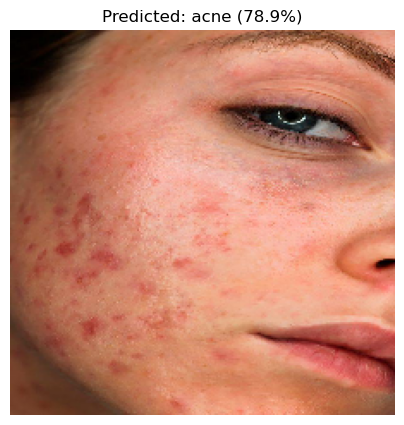

Full ranking:
  acne          78.9%
  blackheads    14.0%
  pores          2.2%
  darkspots      2.2%
  wrinkles       1.6%
  clearskin      1.2%


In [4]:
import matplotlib.pyplot as plt

def show_prediction(img_path):
    ranked, raw_img = predict_skin_condition(img_path)
    top_label, top_prob = ranked[0]

    plt.figure(figsize=(5,5))
    plt.imshow(raw_img[0].astype("uint8"))
    plt.title(f"Predicted: {top_label} ({top_prob*100:.1f}%)")
    plt.axis("off")
    plt.show()

    print("Full ranking:")
    for label, prob in ranked:
        print(f"  {label:12s} {prob*100:5.1f}%")

    return top_label


predicted_class = show_prediction(r"C:\Users\gurup\OneDrive\Desktop\AI-Skin-Classifier\Data sets\acne\0_before_jpg.rf.db1b0102231c11d9d92d42a9a13c6ffb.jpg")